In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def ciou_loss(pred_boxes, target_boxes):

    # Boxes format:
    # [x_center, y_center, width, height]

    pred_x, pred_y, pred_w, pred_h = pred_boxes.T
    target_x, target_y, target_w, target_h = target_boxes.T


    # Convert center format to corners

    pred_x1 = pred_x - pred_w / 2
    pred_y1 = pred_y - pred_h / 2
    pred_x2 = pred_x + pred_w / 2
    pred_y2 = pred_y + pred_h / 2


    target_x1 = target_x - target_w / 2
    target_y1 = target_y - target_h / 2
    target_x2 = target_x + target_w / 2
    target_y2 = target_y + target_h / 2



    # Intersection

    inter_x1 = torch.max(pred_x1,target_x1)
    inter_y1 = torch.max(pred_y1,target_y1)
    inter_x2 = torch.min(pred_x2,target_x2)
    inter_y2 = torch.min(pred_y2,target_y2)


    inter_area = (
        torch.clamp(inter_x2-inter_x1,min=0) *
        torch.clamp(inter_y2-inter_y1,min=0)
    )


    # Union

    pred_area = pred_w * pred_h
    target_area = target_w * target_h


    union = pred_area + target_area - inter_area


    iou = inter_area/(union+1e-7)



    # Center distance

    center_distance = (
        (pred_x-target_x)**2 +
        (pred_y-target_y)**2
    )


    # Enclosing box diagonal

    c_x1=torch.min(pred_x1,target_x1)
    c_y1=torch.min(pred_y1,target_y1)

    c_x2=torch.max(pred_x2,target_x2)
    c_y2=torch.max(pred_y2,target_y2)


    diagonal = (
        (c_x2-c_x1)**2 +
        (c_y2-c_y1)**2
    )


    distance_term=center_distance/(diagonal+1e-7)



    # Aspect ratio penalty

    v = (4/(np.pi**2))*(
        torch.atan(target_w/target_h)
        -
        torch.atan(pred_w/pred_h)
    )**2


    alpha = v/(1-iou+v+1e-7)



    ciou = iou - distance_term - alpha*v


    loss = 1-ciou


    return loss.mean()

In [3]:
def classification_loss(pred_cls,target_cls):

    loss = F.binary_cross_entropy_with_logits(
        pred_cls,
        target_cls
    )

    return loss

In [4]:
def assign_targets(pred_boxes, target_boxes):

    num_preds = pred_boxes.shape[0]

    assigned_targets=torch.zeros_like(pred_boxes)


    distance = torch.cdist(
        pred_boxes[:,:2],
        target_boxes[:,:2]
    )


    indexes=torch.argmin(distance,dim=1)


    for i,index in enumerate(indexes):

        assigned_targets[i]=target_boxes[index]


    return assigned_targets

In [5]:
class YOLOLoss(nn.Module):

    def __init__(self,
                 box_weight=7.5,
                 cls_weight=0.5):

        super().__init__()

        self.box_weight=box_weight
        self.cls_weight=cls_weight



    def forward(self,
                pred_boxes,
                target_boxes,
                pred_cls,
                target_cls):


        box_loss = ciou_loss(
            pred_boxes,
            target_boxes
        )


        cls_loss = classification_loss(
            pred_cls,
            target_cls
        )


        total_loss = (
            self.box_weight*box_loss
            +
            self.cls_weight*cls_loss
        )


        return total_loss,box_loss,cls_loss

In [6]:
pred_boxes=torch.tensor([
    [0.5,0.5,0.3,0.4],
    [0.2,0.4,0.2,0.3]
],
dtype=torch.float32)



target_boxes=torch.tensor([
    [0.52,0.48,0.32,0.38],
    [0.25,0.42,0.22,0.28]
],
dtype=torch.float32)



pred_cls=torch.tensor(
    [[2.0],
     [1.5]]
)


target_cls=torch.tensor(
    [[1.0],
     [1.0]]
)

In [7]:
criterion=YOLOLoss()


total,box,cls = criterion(
    pred_boxes,
    target_boxes,
    pred_cls,
    target_cls
)


print("Total Loss:",total.item())
print("Box Loss:",box.item())
print("Classification Loss:",cls.item())

Total Loss: 2.597017288208008
Box Loss: 0.3353242576122284
Classification Loss: 0.16417065262794495


In [9]:
loss_history=[]

# Make pred_boxes and pred_cls require gradients for optimization demonstration
pred_boxes.requires_grad_(True)
pred_cls.requires_grad_(True)

# Define an optimizer
optimizer = torch.optim.Adam([pred_boxes, pred_cls], lr=0.01)


for epoch in range(20):

    optimizer.zero_grad()


    loss,box_loss,cls_loss = criterion(
        pred_boxes,
        target_boxes,
        pred_cls,
        target_cls
    )


    loss.backward()

    optimizer.step()


    loss_history.append(loss.item())


    print(
        "Epoch:",
        epoch+1,
        "Loss:",
        loss.item()
    )

Epoch: 1 Loss: 2.597017288208008
Epoch: 2 Loss: 1.9860801696777344
Epoch: 3 Loss: 1.4580923318862915
Epoch: 4 Loss: 1.1639647483825684
Epoch: 5 Loss: 0.8782188892364502
Epoch: 6 Loss: 0.8304411768913269
Epoch: 7 Loss: 0.7845668792724609
Epoch: 8 Loss: 0.9826135039329529
Epoch: 9 Loss: 1.107177734375
Epoch: 10 Loss: 1.0966442823410034
Epoch: 11 Loss: 1.01993727684021
Epoch: 12 Loss: 0.8671301603317261
Epoch: 13 Loss: 0.6917805671691895
Epoch: 14 Loss: 0.5887653827667236
Epoch: 15 Loss: 0.4499233365058899
Epoch: 16 Loss: 0.33355191349983215
Epoch: 17 Loss: 0.46126317977905273
Epoch: 18 Loss: 0.5097730159759521
Epoch: 19 Loss: 0.47769373655319214
Epoch: 20 Loss: 0.47758638858795166


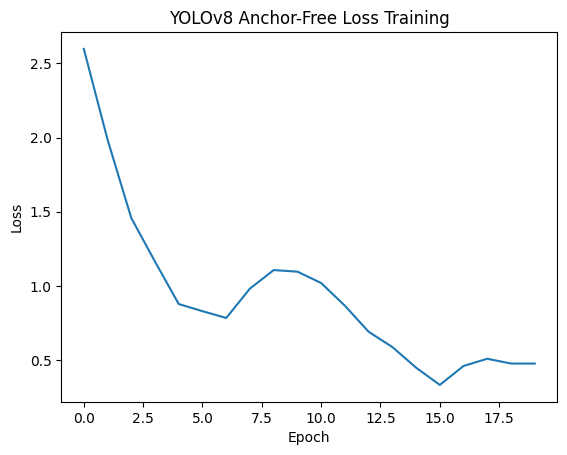

In [10]:
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "YOLOv8 Anchor-Free Loss Training"
)

plt.show()